<a href="https://colab.research.google.com/github/ariandit/user_arian/blob/master/script_klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

print("data_hasil_cluster.xlsx")
uploaded = files.upload()

data_hasil_cluster.xlsx


Saving data_hasil_cluster.xlsx to data_hasil_cluster (1).xlsx


In [ ]:
data = pd.read_excel("data_hasil_cluster.xlsx")

print("Jumlah data:", len(data))
print("Nama kolom:", list(data.columns))


Jumlah data: 136
Nama kolom: ['DESA', 'NDVI', 'SAVI', 'NDWI', 'MNDWI', 'VCI', 'Cluster']


In [ ]:
if 'Cluster' not in data.columns:
    raise ValueError("Kolom 'Cluster' tidak ditemukan di dataset! Pastikan nama kolom sesuai.")

X = data.select_dtypes(include=[np.number]).drop(columns=['Cluster'], errors='ignore')
y = data['Cluster']

print("\nJumlah fitur:", X.shape[1])
print("Jumlah target unik:", y.nunique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Jumlah fitur: 5
Jumlah target unik: 2



Akurasi Model Random Forest: 97.56%

=== Laporan Klasifikasi ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        37
           1       1.00      0.75      0.86         4

    accuracy                           0.98        41
   macro avg       0.99      0.88      0.92        41
weighted avg       0.98      0.98      0.97        41



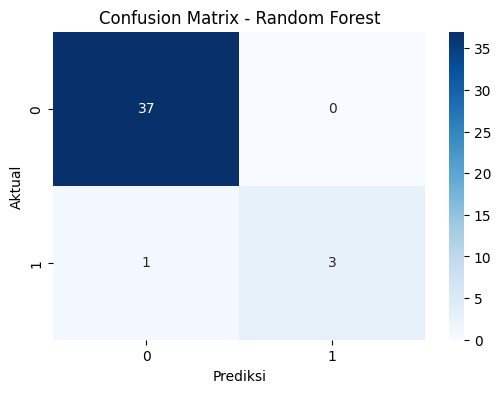


=== Feature Importance ===


,Fitur,Kepentingan
3,MNDWI,0.391735
0,NDVI,0.302058
1,SAVI,0.239816
4,VCI,0.056072
2,NDWI,0.010320


In [ ]:
# klasifikasi menggunakan Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_test = rf.predict(X_test_scaled)

akurasi = accuracy_score(y_test, y_pred_test)
print(f"\nAkurasi Model Random Forest: {akurasi*100:.2f}%\n")
print("=== Laporan Klasifikasi ===")
print(classification_report(y_test, y_pred_test))


plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Kepentingan': rf.feature_importances_
}).sort_values(by='Kepentingan', ascending=False)

print("\n=== Feature Importance ===")
display(feature_importance.style.background_gradient(cmap='YlGnBu'))

# Prediksi untuk seluruh 137 data
X_scaled_all = scaler.fit_transform(X)
y_pred_all = rf.predict(X_scaled_all)

# Tambahkan hasil prediksi ke data asli
data['Cluster_Prediksi'] = y_pred_all

In [ ]:
# menyimpan file ke xlsx
output_file = "Klasifikasi_RandomForest.xlsx"

with pd.ExcelWriter(output_file) as writer:
    data.to_excel(writer, sheet_name="Data_dengan_Prediksi", index=False)
    feature_importance.to_excel(writer, sheet_name="Feature_Importance", index=False)

print(f"\n File hasil klasifikasi lengkap disimpan ke: {output_file}")
print(f"Jumlah baris data hasil klasifikasi: {len(data)}")


 File hasil klasifikasi lengkap disimpan ke: Klasifikasi_RandomForest.xlsx
Jumlah baris data hasil klasifikasi: 136
